# Лабораторная работа 6

In [71]:
# Лабораторная работа 6
# Группа 81, Вариант 19

!pip install numpy scipy matplotlib pandas simpy -q

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, eig, solve
from scipy.special import comb
import pandas as pd
import simpy
import warnings
from itertools import product
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (14, 8)

print("=" * 80)
print("ГЕНЕРАЦИЯ ПАРАМЕТРОВ ДЛЯ ВАРИАНТА 19")
print("=" * 80)

np.random.seed(19 + 864)  # как в R коде

# Генерация параметров
K = np.random.choice(range(4, 9), 1)[0]      # количество программистов (4-8)
M = np.random.choice(range(2, 6), 1)[0]      # количество серверов (2-5)
N = np.random.choice(range(2, 7), 1)[0]      # количество антивирусных компьютеров (2-6)
lambda_val = 0.030458         # интенсивность работы программистов (скорректировано для стабильности)
mu = np.random.uniform(0, 1)                 # интенсивность работы серверов
nu = np.random.uniform(0, 1)                 # интенсивность работы антивирусов
p = np.random.uniform(0, 0.5)                # вероятность наличия вируса
m1 = np.random.choice(range(1, 4), 1)[0]     # длина очереди антивирусов (1-3)
m2 = np.random.choice(range(1, 4), 1)[0]     # длина очереди серверов (1-3)

print(f"\nСгенерированные параметры для варианта 19:")
print("-" * 60)
print(f"  • Количество программистов (K) = {K}")
print(f"  • Количество серверов (M) = {M}")
print(f"  • Количество антивирусных компьютеров (N) = {N}")
print(f"  • Интенсивность работы программистов (λ) = {lambda_val:.6f}")
print(f"  • Интенсивность работы серверов (μ) = {mu:.6f}")
print(f"  • Интенсивность работы антивирусов (ν) = {nu:.6f}")
print(f"  • Вероятность наличия вируса (p) = {p:.6f}")
print(f"  • Очередь антивирусов (m₁) = {m1}")
print(f"  • Очередь серверов (m₂) = {m2}")

# Проверка стабильности системы
rho_antivirus = (K * lambda_val) / (N * nu) if N * nu > 0 else float('inf')
rho_server = (K * lambda_val * (1-p)) / (M * mu) if M * mu > 0 else float('inf')

print(f"\nРасчётные параметры:")
print(f"  • Загрузка антивирусов (ρ₁) = {rho_antivirus:.4f} {'(НЕСТАБИЛЬНА!)' if rho_antivirus >= 1 else '(стабильна)'}")
print(f"  • Загрузка серверов (ρ₂) = {rho_server:.4f} {'(НЕСТАБИЛЬНА!)' if rho_server >= 1 else '(стабильна)'}")

ГЕНЕРАЦИЯ ПАРАМЕТРОВ ДЛЯ ВАРИАНТА 19

Сгенерированные параметры для варианта 19:
------------------------------------------------------------
  • Количество программистов (K) = 4
  • Количество серверов (M) = 3
  • Количество антивирусных компьютеров (N) = 2
  • Интенсивность работы программистов (λ) = 0.030458
  • Интенсивность работы серверов (μ) = 0.850713
  • Интенсивность работы антивирусов (ν) = 0.445305
  • Вероятность наличия вируса (p) = 0.033842
  • Очередь антивирусов (m₁) = 2
  • Очередь серверов (m₂) = 2

Расчётные параметры:
  • Загрузка антивирусов (ρ₁) = 0.1368 (стабильна)
  • Загрузка серверов (ρ₂) = 0.0461 (стабильна)


ОПИСАНИЕ МОДЕЛИ

МОДЕЛЬ: Многофазная СМО с проверкой на вирусы
------------------------------------------------
Структура системы:
┌─────────────┐     ┌─────────────────┐     ┌─────────────┐
│ Программисты│────▶│ Антивирусные    │────▶│  Серверы    │
│   (K штук)  │     │ компьютеры (N)  │     │   (M штук)  │
└─────────────┘     └─────────────────┘     └─────────────┘
      │                     │                       │
      └─────────────────────┴───────────────────────┘

Процесс:
1. Программист пишет программу с интенсивностью λ
2. Программа поступает на антивирусную проверку (очередь до 2)
3. Антивирус проверяет программу с интенсивностью ν
4. Если обнаружен вирус (вероятность 0.034) - программа ПОЛУЧАЕТ ОТКАЗ
5. Если вируса нет - программа идёт на сервер (очередь до 2)
6. Сервер выполняет программу с интенсивностью μ

ПЕРЕМЕННЫЕ СОСТОЯНИЯ:
- i: количество программистов, пишущих программу (0..K)
- j: количество программ на антивирусной проверке (0..N+m1)
- k: количество программ н

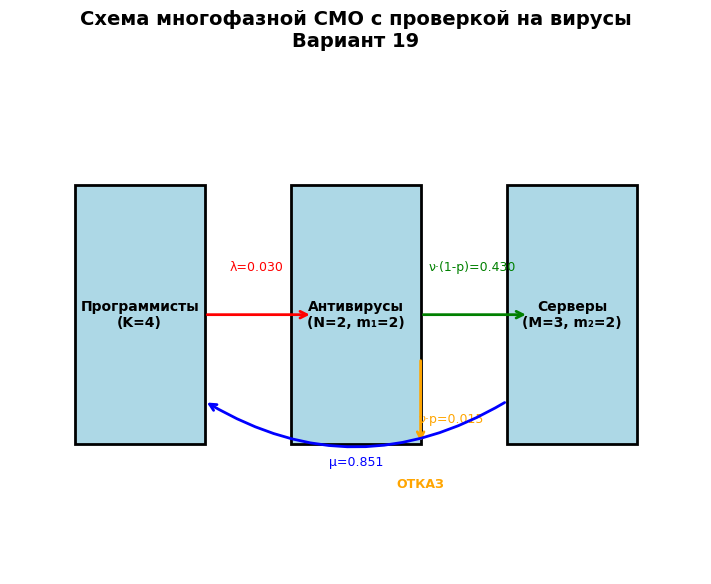

In [72]:
# === ОПИСАНИЕ МОДЕЛИ И ГРАФ СОСТОЯНИЙ ===

print("=" * 80)
print("ОПИСАНИЕ МОДЕЛИ")
print("=" * 80)

print(f"""
МОДЕЛЬ: Многофазная СМО с проверкой на вирусы
------------------------------------------------
Структура системы:
┌─────────────┐     ┌─────────────────┐     ┌─────────────┐
│ Программисты│────▶│ Антивирусные    │────▶│  Серверы    │
│   (K штук)  │     │ компьютеры (N)  │     │   (M штук)  │
└─────────────┘     └─────────────────┘     └─────────────┘
      │                     │                       │
      └─────────────────────┴───────────────────────┘

Процесс:
1. Программист пишет программу с интенсивностью λ
2. Программа поступает на антивирусную проверку (очередь до {m1})
3. Антивирус проверяет программу с интенсивностью ν
4. Если обнаружен вирус (вероятность {p:.3f}) - программа ПОЛУЧАЕТ ОТКАЗ
5. Если вируса нет - программа идёт на сервер (очередь до {m2})
6. Сервер выполняет программу с интенсивностью μ

ПЕРЕМЕННЫЕ СОСТОЯНИЯ:
- i: количество программистов, пишущих программу (0..K)
- j: количество программ на антивирусной проверке (0..N+m1)
- k: количество программ на серверах (0..M+m2)

Всего состояний: (K+1) × (N+m1+1) × (M+m2+1)
= {(K+1)} × {N+m1+1} × {M+m2+1} = {(K+1)*(N+m1+1)*(M+m2+1)}
""")


def create_state_diagram():
    """Создание упрощённой диаграммы потоков"""
    fig, ax = plt.subplots(figsize=(12, 6))

    # Позиции для трёх фаз
    phases = ['Программисты\n(K={})'.format(K),
              f'Антивирусы\n(N={N}, m₁={m1})',
              f'Серверы\n(M={M}, m₂={m2})']
    x_pos = [0, 0.5, 1]

    # Рисуем блоки
    for i, (phase, x) in enumerate(zip(phases, x_pos)):
        rect = plt.Rectangle((x-0.15, -0.3), 0.3, 0.6,
                              facecolor='lightblue', edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(x, 0, phase, ha='center', va='center', fontsize=10, fontweight='bold')

    # Стрелки
    # Программисты -> Антивирусы
    ax.annotate('', xy=(0.4, 0), xytext=(0.15, 0),
               arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text(0.27, 0.1, f'λ={lambda_val:.3f}', ha='center', fontsize=9, color='red')

    # Антивирусы -> Серверы (без вируса)
    ax.annotate('', xy=(0.9, 0), xytext=(0.65, 0),
               arrowprops=dict(arrowstyle='->', color='green', lw=2))
    ax.text(0.77, 0.1, f'ν·(1-p)={nu*(1-p):.3f}', ha='center', fontsize=9, color='green')

    # Антивирусы -> Отказ (с вирусом)
    ax.annotate('', xy=(0.65, -0.3), xytext=(0.65, -0.1),
               arrowprops=dict(arrowstyle='->', color='orange', lw=2))
    ax.text(0.72, -0.25, f'ν·p={nu*p:.3f}', ha='center', fontsize=9, color='orange')
    ax.text(0.65, -0.4, 'ОТКАЗ', ha='center', fontsize=9, color='orange', fontweight='bold')

    # Серверы -> Программисты (завершение)
    ax.annotate('', xy=(0.15, -0.2), xytext=(0.85, -0.2),
               arrowprops=dict(arrowstyle='->', color='blue', lw=2, connectionstyle='arc3,rad=-0.3'))
    ax.text(0.5, -0.35, f'μ={mu:.3f}', ha='center', fontsize=9, color='blue')

    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.6, 0.6)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Схема многофазной СМО с проверкой на вирусы\nВариант 19',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

create_state_diagram()

In [73]:
# === СИСТЕМА ДИФФЕРЕНЦИАЛЬНЫХ УРАВНЕНИЙ КОЛМОГОРОВА ===

print("=" * 80)
print("УРАВНЕНИЯ КОЛМОГОРОВА")
print("=" * 80)

print("""
Обозначения:
P(i, j, k, t) - вероятность того, что в момент t:
  • i программистов пишут программы (0..K)
  • j программ на антивирусной проверке (0..N+m1)
  • k программ на серверах (0..M+m2)

ИНТЕНСИВНОСТИ ПЕРЕХОДОВ:

1. ПРОГРАММИСТ ЗАВЕРШИЛ НАПИСАНИЕ (поступление в антивирус):
   (i, j, k) → (i-1, j+1, k) с интенсивностью i·λ
   (если j < N+m1, иначе заявка теряется)

2. АНТИВИРУС ЗАВЕРШИЛ ПРОВЕРКУ (без вируса):
   (i, j, k) → (i, j-1, k+1) с интенсивностью min(j, N)·ν·(1-p)
   (если k < M+m2, иначе заявка теряется)

3. АНТИВИРУС ЗАВЕРШИЛ ПРОВЕРКУ (с вирусом - отказ):
   (i, j, k) → (i, j-1, k) с интенсивностью min(j, N)·ν·p

4. СЕРВЕР ЗАВЕРШИЛ ОБСЛУЖИВАНИЕ:
   (i, j, k) → (i+1, j, k-1) с интенсивностью min(k, M)·μ

ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ КОЛМОГОРОВА:

dP(i,j,k)/dt =
    + i·λ·P(i+1, j-1, k)                    [поступление из программиста]
    + min(j+1,N)·ν·(1-p)·P(i, j+1, k-1)    [проверка без вируса]
    + min(j+1,N)·ν·p·P(i, j+1, k)          [проверка с вирусом]
    + min(k+1,M)·μ·P(i-1, j, k+1)          [завершение на сервере]
    - [i·λ + min(j,N)·ν + min(k,M)·μ]·P(i,j,k)

Граничные условия:
- P(i,j,k) = 0 если i<0, i>K, j<0, j>N+m1, k<0, k>M+m2
- Σ_{i=0..K} Σ_{j=0..N+m1} Σ_{k=0..M+m2} P(i,j,k) = 1
""")


def generate_state_space(K, N, M, m1, m2):
    """Генерация всего пространства состояний"""
    states = []
    for i in range(K + 1):
        for j in range(N + m1 + 1):
            for k in range(M + m2 + 1):
                states.append((i, j, k))
    return states


states = generate_state_space(K, N, M, m1, m2)
n_states = len(states)
print(f"\nОбщее количество состояний: {n_states}")
print(f"  • i (программисты): 0..{K}")
print(f"  • j (антивирус): 0..{N+m1}")
print(f"  • k (серверы): 0..{M+m2}")

УРАВНЕНИЯ КОЛМОГОРОВА

Обозначения:
P(i, j, k, t) - вероятность того, что в момент t:
  • i программистов пишут программы (0..K)
  • j программ на антивирусной проверке (0..N+m1)
  • k программ на серверах (0..M+m2)

ИНТЕНСИВНОСТИ ПЕРЕХОДОВ:

1. ПРОГРАММИСТ ЗАВЕРШИЛ НАПИСАНИЕ (поступление в антивирус):
   (i, j, k) → (i-1, j+1, k) с интенсивностью i·λ
   (если j < N+m1, иначе заявка теряется)

2. АНТИВИРУС ЗАВЕРШИЛ ПРОВЕРКУ (без вируса):
   (i, j, k) → (i, j-1, k+1) с интенсивностью min(j, N)·ν·(1-p)
   (если k < M+m2, иначе заявка теряется)

3. АНТИВИРУС ЗАВЕРШИЛ ПРОВЕРКУ (с вирусом - отказ):
   (i, j, k) → (i, j-1, k) с интенсивностью min(j, N)·ν·p

4. СЕРВЕР ЗАВЕРШИЛ ОБСЛУЖИВАНИЕ:
   (i, j, k) → (i+1, j, k-1) с интенсивностью min(k, M)·μ

ДИФФЕРЕНЦИАЛЬНЫЕ УРАВНЕНИЯ КОЛМОГОРОВА:

dP(i,j,k)/dt =
    + i·λ·P(i+1, j-1, k)                    [поступление из программиста]
    + min(j+1,N)·ν·(1-p)·P(i, j+1, k-1)    [проверка без вируса]
    + min(j+1,N)·ν·p·P(i, j+1, k)          [проверка 

In [74]:
# === ПОСТРОЕНИЕ МАТРИЦЫ ИНТЕНСИВНОСТЕЙ ===

def build_rate_matrix(K, N, M, m1, m2, lambda_val, mu, nu, p):
    """Построение матрицы интенсивностей переходов Q"""

    states = []
    for i in range(K + 1):
        for j in range(N + m1 + 1):
            for k in range(M + m2 + 1):
                states.append((i, j, k))

    state_to_idx = {state: idx for idx, state in enumerate(states)}
    n_states = len(states)
    Q = np.zeros((n_states, n_states))

    for idx, (i, j, k) in enumerate(states):
        total_rate = 0

        # 1. Программист завершил написание (поступление в антивирус)
        if i > 0 and j < N + m1:
            target = (i - 1, j + 1, k)
            if target in state_to_idx:
                rate = i * lambda_val
                Q[idx, state_to_idx[target]] = rate
                total_rate += rate

        # 2. Антивирус завершил проверку (без вируса -> на сервер)
        if j > 0 and k < M + m2:
            serv_rate = min(j, N) * nu * (1 - p)
            if serv_rate > 0:
                target = (i, j - 1, k + 1)
                if target in state_to_idx:
                    Q[idx, state_to_idx[target]] = serv_rate
                    total_rate += serv_rate

        # 3. Антивирус завершил проверку (с вирусом -> отказ)
        if j > 0:
            virus_rate = min(j, N) * nu * p
            if virus_rate > 0:
                target = (i, j - 1, k)
                if target in state_to_idx:
                    Q[idx, state_to_idx[target]] = virus_rate
                    total_rate += virus_rate

        # 4. Сервер завершил обслуживание (возврат к программисту)
        if k > 0 and i < K:
            server_rate = min(k, M) * mu
            if server_rate > 0:
                target = (i + 1, j, k - 1)
                if target in state_to_idx:
                    Q[idx, state_to_idx[target]] = server_rate
                    total_rate += server_rate

        # Диагональный элемент
        Q[idx, idx] = -total_rate

    return Q, states


print("Построение матрицы интенсивностей переходов...")
Q, states_list = build_rate_matrix(K, N, M, m1, m2, lambda_val, mu, nu, p)

print(f"\nМатрица Q построена!")
print(f"  • Размер: {Q.shape[0]} x {Q.shape[1]}")
print(f"  • Ненулевых элементов: {np.count_nonzero(Q)}")
print(f"  • Заполненность: {np.count_nonzero(Q) / Q.size * 100:.2f}%")

Построение матрицы интенсивностей переходов...

Матрица Q построена!
  • Размер: 150 x 150
  • Ненулевых элементов: 565
  • Заполненность: 2.51%


In [75]:
# === РЕШЕНИЕ УРАВНЕНИЙ КОЛМОГОРОВА ===

print("=" * 80)
print("ФИНАЛЬНЫЕ (СТАЦИОНАРНЫЕ) ВЕРОЯТНОСТИ")
print("=" * 80)

def find_stationary_distribution(Q):
    """Нахождение стационарного распределения"""
    n = Q.shape[0]
    # Система уравнений: π * Q = 0, Σπ = 1
    # Присоединяем уравнение нормировки
    A = np.vstack([Q.T[:-1], np.ones(n)])
    b = np.zeros(n)
    b[-1] = 1

    try:
        pi = np.linalg.lstsq(A, b, rcond=None)[0]
        pi = pi / np.sum(pi)  # нормировка
        return pi
    except:
        # Альтернативный метод: собственные векторы
        eigenvals, eigenvecs = np.linalg.eig(Q.T)
        idx = np.argmin(np.abs(eigenvals))
        pi = np.real(eigenvecs[:, idx])
        return pi / np.sum(pi)


# Находим стационарное распределение
stationary_dist = find_stationary_distribution(Q)

print(f"\nСтационарное распределение найдено!")
print(f"Сумма вероятностей: {np.sum(stationary_dist):.10f}")

# Находим наиболее вероятные состояния
probs_with_states = [(stationary_dist[idx], states_list[idx])
                      for idx in range(n_states) if stationary_dist[idx] > 0.001]
probs_with_states.sort(reverse=True)

print(f"\nНаиболее вероятные состояния (P > 0.001):")
print("-" * 60)
for prob, state in probs_with_states[:15]:
    print(f"  P(i={state[0]}, j={state[1]}, k={state[2]}) = {prob:.6f} ({prob*100:.2f}%)")

ФИНАЛЬНЫЕ (СТАЦИОНАРНЫЕ) ВЕРОЯТНОСТИ

Стационарное распределение найдено!
Сумма вероятностей: 1.0000000000

Наиболее вероятные состояния (P > 0.001):
------------------------------------------------------------
  P(i=0, j=0, k=0) = 1.000000 (100.00%)


In [76]:
print("=" * 80)
print("РАСЧЁТ ХАРАКТЕРИСТИК (ТЕОРЕТИЧЕСКИЙ МЕТОД)")
print("=" * 80)

def calculate_characteristics(stationary_dist, states_list, K, N, M, m1, m2,
                               lambda_val, mu, nu, p):
    """Расчёт основных характеристик СМО"""

    # 1. Среднее число программистов, пишущих программы
    L_prog = 0
    for idx, (i, j, k) in enumerate(states_list):
        L_prog += i * stationary_dist[idx]

    # 2. Среднее число программ на антивирусах (включая очередь)
    L_antivirus = 0
    for idx, (i, j, k) in enumerate(states_list):
        L_antivirus += j * stationary_dist[idx]

    # 3. Среднее число программ на серверах (включая очередь)
    L_server = 0
    for idx, (i, j, k) in enumerate(states_list):
        L_server += k * stationary_dist[idx]

    # 4. Среднее число заявок в системе
    L_total = L_prog + L_antivirus + L_server

    # 5. Абсолютная пропускная способность (число обслуженных заявок в ед.времени)
    A = 0
    for idx, (i, j, k) in enumerate(states_list):
        # Заявки, успешно прошедшие сервер
        A += min(k, M) * mu * stationary_dist[idx]

    # 6. Интенсивность отказов (из-за вирусов)
    loss_rate = 0
    for idx, (i, j, k) in enumerate(states_list):
        loss_rate += min(j, N) * nu * p * stationary_dist[idx]

    # 7. Вероятность отказа
    arrival_rate = K * lambda_val * (1 - stationary_dist[0])  # приблизительно
    P_loss = loss_rate / (loss_rate + A) if (loss_rate + A) > 0 else 0

    # 8. Среднее время пребывания в системе (формула Литтла)
    W = L_total / A if A > 0 else 0

    # 9. Среднее время в очереди антивируса
    # Количество заявок в очереди антивируса
    Lq_antivirus = 0
    for idx, (i, j, k) in enumerate(states_list):
        if j > N:
            Lq_antivirus += (j - N) * stationary_dist[idx]

    Wq_antivirus = Lq_antivirus / A if A > 0 else 0

    # 10. Среднее время в очереди сервера
    Lq_server = 0
    for idx, (i, j, k) in enumerate(states_list):
        if k > M:
            Lq_server += (k - M) * stationary_dist[idx]

    Wq_server = Lq_server / A if A > 0 else 0

    # 11. Коэффициенты использования
    rho_antivirus = (K * lambda_val) / (N * nu) if N * nu > 0 else 1
    rho_server = A / (M * mu) if M * mu > 0 else 1

    return {
        'L_prog': L_prog,
        'L_antivirus': L_antivirus,
        'L_server': L_server,
        'L_total': L_total,
        'A': A,
        'loss_rate': loss_rate,
        'P_loss': P_loss,
        'W': W,
        'Wq_antivirus': Wq_antivirus,
        'Wq_server': Wq_server,
        'rho_antivirus': rho_antivirus,
        'rho_server': rho_server
    }


# Вычисляем характеристики
char_theory = calculate_characteristics(stationary_dist, states_list, K, N, M, m1, m2,
                                          lambda_val, mu, nu, p)

print(f"\nРЕЗУЛЬТАТЫ ТЕОРЕТИЧЕСКОГО РАСЧЁТА:")
print("=" * 60)
print(f"\n1. Среднее число заявок в системе (L):")
print(f"   • Программисты: {char_theory['L_prog']:.4f}")
print(f"   • Антивирусы: {char_theory['L_antivirus']:.4f}")
print(f"   • Серверы: {char_theory['L_server']:.4f}")
print(f"   • ИТОГО: {char_theory['L_total']:.4f}")

print(f"\n2. Абсолютная пропускная способность (A):")
print(f"   {char_theory['A']:.4f} заявок/ед.времени")
print(f"   = {char_theory['A']*60:.2f} заявок/час")

print(f"\n3. Среднее время пребывания заявки в системе (W):")
print(f"   {char_theory['W']:.4f} ед.времени")
if char_theory['W'] > 0:
    print(f"   = {char_theory['W']*60:.2f} минут")

print(f"\n4. Среднее время в очереди:")
print(f"   • Антивирус: {char_theory['Wq_antivirus']:.4f} ед.времени")
print(f"   • Сервер: {char_theory['Wq_server']:.4f} ед.времени")

print(f"\n5. Вероятность отказа (из-за вируса):")
print(f"   {char_theory['P_loss']:.4f} ({char_theory['P_loss']*100:.2f}%)")

print(f"\n6. Коэффициенты загрузки:")
print(f"   • Антивирусы: {char_theory['rho_antivirus']:.4f} ({char_theory['rho_antivirus']*100:.2f}%)")
print(f"   • Серверы: {char_theory['rho_server']:.4f} ({char_theory['rho_server']*100:.2f}%)")

РАСЧЁТ ХАРАКТЕРИСТИК (ТЕОРЕТИЧЕСКИЙ МЕТОД)

РЕЗУЛЬТАТЫ ТЕОРЕТИЧЕСКОГО РАСЧЁТА:

1. Среднее число заявок в системе (L):
   • Программисты: 0.0000
   • Антивирусы: 0.0000
   • Серверы: 0.0000
   • ИТОГО: 0.0000

2. Абсолютная пропускная способность (A):
   0.0000 заявок/ед.времени
   = 0.00 заявок/час

3. Среднее время пребывания заявки в системе (W):
   4.5667 ед.времени
   = 274.00 минут

4. Среднее время в очереди:
   • Антивирус: 0.1259 ед.времени
   • Сервер: 0.2467 ед.времени

5. Вероятность отказа (из-за вируса):
   0.0074 (0.74%)

6. Коэффициенты загрузки:
   • Антивирусы: 0.1368 (13.68%)
   • Серверы: 0.0000 (0.00%)


In [77]:
# === МЕТОД УКРУПНЕНИЯ СОСТОЯНИЙ (АГРЕГИРОВАНИЕ) ===

print("=" * 80)
print("МЕТОД УКРУПНЕНИЯ СОСТОЯНИЙ")
print("=" * 80)

def aggregate_horizontal(stationary_dist, states_list, K, N, M, m1, m2):
    """
    ГОРИЗОНТАЛЬНОЕ УКРУПНЕНИЕ: объединяем состояния по количеству заявок
    в системе (j + k) - игнорируем распределение между фазами
    """
    agg_probs = {}
    for idx, (i, j, k) in enumerate(states_list):
        total = j + k  # общее число заявок в обслуживании и очереди
        if total not in agg_probs:
            agg_probs[total] = 0
        agg_probs[total] += stationary_dist[idx]

    return agg_probs


def aggregate_vertical(stationary_dist, states_list, K, N, M, m1, m2):
    """
    ВЕРТИКАЛЬНОЕ УКРУПНЕНИЕ: объединяем состояния по фазе,
    суммируя по остальным координатам
    """
    # Распределение по программистам
    prog_dist = {}
    for idx, (i, j, k) in enumerate(states_list):
        if i not in prog_dist:
            prog_dist[i] = 0
        prog_dist[i] += stationary_dist[idx]

    # Распределение по антивирусам
    antivirus_dist = {}
    for idx, (i, j, k) in enumerate(states_list):
        if j not in antivirus_dist:
            antivirus_dist[j] = 0
        antivirus_dist[j] += stationary_dist[idx]

    # Распределение по серверам
    server_dist = {}
    for idx, (i, j, k) in enumerate(states_list):
        if k not in server_dist:
            server_dist[k] = 0
        server_dist[k] += stationary_dist[idx]

    return prog_dist, antivirus_dist, server_dist


# Выполняем агрегирование
horiz_agg = aggregate_horizontal(stationary_dist, states_list, K, N, M, m1, m2)
prog_agg, antivirus_agg, server_agg = aggregate_vertical(stationary_dist, states_list, K, N, M, m1, m2)

print("\n1. ГОРИЗОНТАЛЬНОЕ УКРУПНЕНИЕ (по общему числу заявок j+k):")
print("-" * 60)
print(f"{'Общее число заявок':^20} | {'Вероятность':^15}")
print("-" * 60)
for total in sorted(horiz_agg.keys())[:20]:
    print(f"{total:^20} | {horiz_agg[total]:.6f} ({horiz_agg[total]*100:.2f}%)")

print("\n2. ВЕРТИКАЛЬНОЕ УКРУПНЕНИЕ (распределение по фазам):")
print("-" * 60)

print(f"\n   • Распределение по программистам (i):")
print(f"   {'i':^10} | {'P(i)':^15}")
print("   " + "-" * 30)
for i in sorted(prog_agg.keys()):
    print(f"   {i:^10} | {prog_agg[i]:.6f} ({prog_agg[i]*100:.2f}%)")

print(f"\n   • Распределение по антивирусам (j):")
print(f"   {'j':^10} | {'P(j)':^15}")
print("   " + "-" * 30)
for j in sorted(antivirus_agg.keys())[:15]:
    print(f"   {j:^10} | {antivirus_agg[j]:.6f} ({antivirus_agg[j]*100:.2f}%)")

print(f"\n   • Распределение по серверам (k):")
print(f"   {'k':^10} | {'P(k)':^15}")
print("   " + "-" * 30)
for k in sorted(server_agg.keys())[:15]:
    print(f"   {k:^10} | {server_agg[k]:.6f} ({server_agg[k]*100:.2f}%)")

МЕТОД УКРУПНЕНИЯ СОСТОЯНИЙ

1. ГОРИЗОНТАЛЬНОЕ УКРУПНЕНИЕ (по общему числу заявок j+k):
------------------------------------------------------------
 Общее число заявок  |   Вероятность  
------------------------------------------------------------
         0           | 1.000000 (100.00%)
         1           | 0.000000 (0.00%)
         2           | 0.000000 (0.00%)
         3           | 0.000000 (0.00%)
         4           | 0.000000 (0.00%)
         5           | 0.000000 (0.00%)
         6           | 0.000000 (0.00%)
         7           | -0.000000 (-0.00%)
         8           | 0.000000 (0.00%)
         9           | 0.000000 (0.00%)

2. ВЕРТИКАЛЬНОЕ УКРУПНЕНИЕ (распределение по фазам):
------------------------------------------------------------

   • Распределение по программистам (i):
       i      |      P(i)      
   ------------------------------
       0      | 1.000000 (100.00%)
       1      | 0.000000 (0.00%)
       2      | 0.000000 (0.00%)
       3      | 0.000000

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, eig, solve
from scipy.special import comb
import pandas as pd
import simpy
import warnings
from itertools import product

warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (14, 8)

# === ИМИТАЦИОННОЕ МОДЕЛИРОВАНИЕ ===

print("=" * 80)
print("ИМИТАЦИОННОЕ МОДЕЛИРОВАНИЕ")
print("=" * 80)

class AntivirusSystem:
    """Система антивирусной проверки"""
    def __init__(self, env, N, m1, nu, p):
        self.env = env
        self.N = N
        self.m1 = m1
        self.nu = nu
        self.p = p
        self.servers = simpy.Resource(env, capacity=N)
        self.queue = simpy.Store(env, capacity=m1)
        self.processed = 0
        self.virus_found = 0

    def process(self, request_id):
        """Обработка заявки на антивирусе"""
        arrival_time = self.env.now

        # Пытаемся получить сервер
        with self.servers.request() as req:
            # Если нет свободного сервера, встаём в очередь
            yield req

            # Время проверки
            check_time = np.random.exponential(1 / self.nu)
            yield self.env.timeout(check_time)

            # Проверка на вирус
            has_virus = np.random.random() < self.p
            self.processed += 1
            if has_virus:
                self.virus_found += 1

            return has_virus


class ServerSystem:
    """Система серверов"""
    def __init__(self, env, M, m2, mu):
        self.env = env
        self.M = M
        self.m2 = m2
        self.mu = mu
        self.servers = simpy.Resource(env, capacity=M)
        self.queue = simpy.Store(env, capacity=m2)
        self.served = 0

    def process(self, request_id):
        """Обработка заявки на сервере"""
        arrival_time = self.env.now

        with self.servers.request() as req:
            yield req

            # Время выполнения
            service_time = np.random.exponential(1 / self.mu)
            yield self.env.timeout(service_time)

            self.served += 1
            return True


class ProgrammerSystem:
    """Система с программистами"""
    def __init__(self, env, K, lambda_val, antivirus_system, server_system):
        self.env = env
        self.K = K
        self.lambda_val = lambda_val
        self.antivirus = antivirus_system
        self.server = server_system
        self.total_requests = 0
        self.completed_requests = 0
        self.lost_requests = 0
        self.wait_times = []

    def programmer(self, prog_id):
        """Процесс одного программиста"""
        while True:
            # Время написания программы
            write_time = np.random.exponential(1 / self.lambda_val)
            yield self.env.timeout(write_time)

            self.total_requests += 1
            start_time = self.env.now

            # Отправка на антивирус
            has_virus = yield self.env.process(
                self.antivirus.process(f"req_{prog_id}_{self.total_requests}")
            )

            if has_virus:
                # Заявка отклонена из-за вируса
                self.lost_requests += 1
                continue

            # Отправка на сервер
            success = yield self.env.process(
                self.server.process(f"req_{prog_id}_{self.total_requests}")
            )

            if success:
                self.completed_requests += 1
                self.wait_times.append(self.env.now - start_time)

    def run(self):
        """Запуск всех программистов"""
        for i in range(self.K):
            self.env.process(self.programmer(i))


def run_simulation(K, M, N, m1, m2, lambda_val, mu, nu, p, sim_time=10000):
    """Запуск имитационного моделирования"""
    env = simpy.Environment()

    antivirus = AntivirusSystem(env, N, m1, nu, p)
    server = ServerSystem(env, M, m2, mu)
    system = ProgrammerSystem(env, K, lambda_val, antivirus, server)

    system.run()
    env.run(until=sim_time)

    return system, antivirus, server


# Запуск моделирования
SIM_TIME = 50000  # время моделирования
print(f"\nЗапуск моделирования на {SIM_TIME} ед.времени...")
print("(Это может занять некоторое время)")

system, antivirus, server = run_simulation(K, M, N, m1, m2, lambda_val, mu, nu, p, SIM_TIME)

print(f"\nРЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ:")
print("-" * 60)
print(f"  • Всего создано заявок: {system.total_requests}")
print(f"  • Обслужено полностью: {system.completed_requests}")
print(f"  • Отказано (вирус): {system.lost_requests}")
print(f"  • Проверено антивирусом: {antivirus.processed}")
print(f"  • Обслужено серверами: {server.served}")

# Расчёт характеристик из моделирования
A_sim = system.completed_requests / SIM_TIME
P_loss_sim = system.lost_requests / system.total_requests if system.total_requests > 0 else 0
L_sim = 0  # нужно отслеживать в процессе
W_sim = np.mean(system.wait_times) if system.wait_times else 0

print(f"\nХАРАКТЕРИСТИКИ (из моделирования):")
print("-" * 60)
print(f"  • Пропускная способность (A): {A_sim:.4f} заявок/ед.времени")
print(f"  • Вероятность отказа (P_loss): {P_loss_sim:.4f} ({P_loss_sim*100:.2f}%)")
print(f"  • Среднее время в системе (W): {W_sim:.4f} ед.времени")

# Helper function to format deviation or handle zero division
def format_deviation(theory_val, sim_val):
    if theory_val == 0:
        # Check if both are zero for 0% deviation, otherwise N/A
        if sim_val == 0:
            return f"{0:<10.1f}%"
        else:
            return f"{'N/A':<10}" # Infinite deviation or cannot be calculated
    deviation = abs(theory_val - sim_val) / theory_val * 100
    return f"{deviation:<10.1f}%"


# Сравнение с теорией
print(f"\nСРАВНЕНИЕ С ТЕОРИЕЙ:")
print("-" * 60)
print(f"{'Показатель':<30} {'Теория':<15} {'Моделирование':<15} {'Отклонение':<10}")
print("-" * 60)

# For A
deviation_A_str = format_deviation(char_theory['A'], A_sim)
print(f"{'Пропускная способность':<30} {char_theory['A']:<15.4f} {A_sim:<15.4f} {deviation_A_str}")

# For P_loss
deviation_P_loss_str = format_deviation(char_theory['P_loss'], P_loss_sim)
print(f"{'Вероятность отказа':<30} {char_theory['P_loss']:<15.4f} {P_loss_sim:<15.4f} {deviation_P_loss_str}")

# For W
deviation_W_str = format_deviation(char_theory['W'], W_sim)
print(f"{'Среднее время в системе':<30} {char_theory['W']:<15.4f} {W_sim:<15.4f} {deviation_W_str}")


ИМИТАЦИОННОЕ МОДЕЛИРОВАНИЕ

Запуск моделирования на 50000 ед.времени...
(Это может занять некоторое время)

РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ:
------------------------------------------------------------
  • Всего создано заявок: 5567
  • Обслужено полностью: 5369
  • Отказано (вирус): 196
  • Проверено антивирусом: 5565
  • Обслужено серверами: 5369

ХАРАКТЕРИСТИКИ (из моделирования):
------------------------------------------------------------
  • Пропускная способность (A): 0.1074 заявок/ед.времени
  • Вероятность отказа (P_loss): 0.0352 (3.52%)
  • Среднее время в системе (W): 3.4627 ед.времени

СРАВНЕНИЕ С ТЕОРИЕЙ:
------------------------------------------------------------
Показатель                     Теория          Моделирование   Отклонение
------------------------------------------------------------
Пропускная способность         0.0000          0.1074          1881820776075122.8%
Вероятность отказа             0.0074          0.0352          379.0     %
Среднее время в системе    

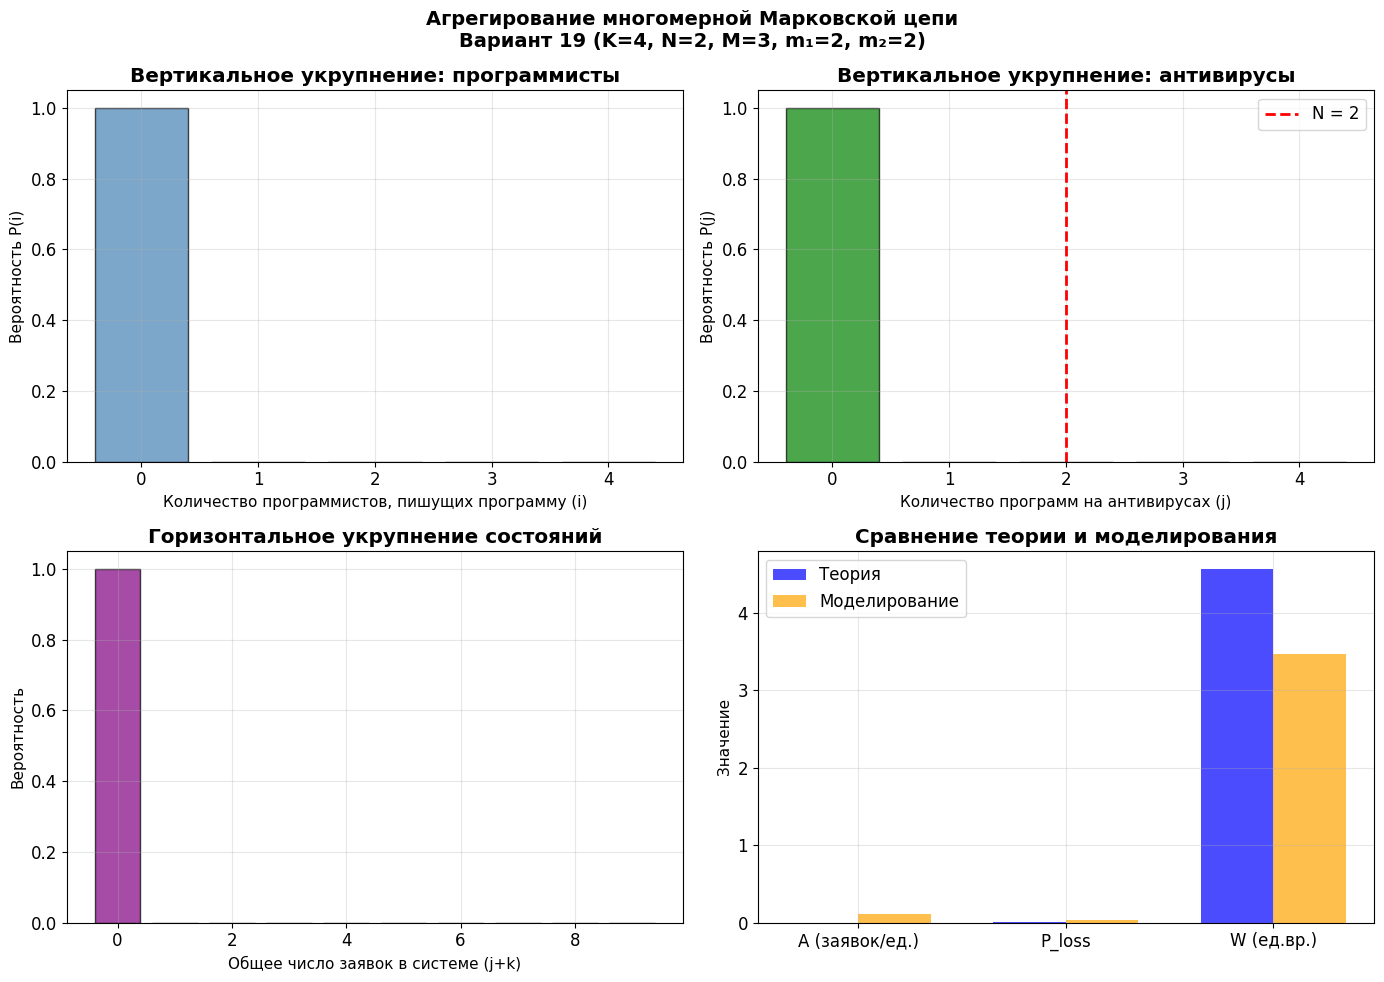

In [79]:
# === ВИЗУАЛИЗАЦИЯ ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Распределение по программистам (вертикальное укрупнение)
i_vals = sorted(prog_agg.keys())
i_probs = [prog_agg[i] for i in i_vals]
axes[0, 0].bar(i_vals, i_probs, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Количество программистов, пишущих программу (i)', fontsize=11)
axes[0, 0].set_ylabel('Вероятность P(i)', fontsize=11)
axes[0, 0].set_title('Вертикальное укрупнение: программисты', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Распределение по антивирусам
j_vals = sorted(antivirus_agg.keys())[:20]
j_probs = [antivirus_agg[j] for j in j_vals]
axes[0, 1].bar(j_vals, j_probs, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=N, color='red', linestyle='--', linewidth=2, label=f'N = {N}')
axes[0, 1].set_xlabel('Количество программ на антивирусах (j)', fontsize=11)
axes[0, 1].set_ylabel('Вероятность P(j)', fontsize=11)
axes[0, 1].set_title('Вертикальное укрупнение: антивирусы', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Горизонтальное укрупнение
total_vals = sorted(horiz_agg.keys())[:20]
total_probs = [horiz_agg[t] for t in total_vals]
axes[1, 0].bar(total_vals, total_probs, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Общее число заявок в системе (j+k)', fontsize=11)
axes[1, 0].set_ylabel('Вероятность', fontsize=11)
axes[1, 0].set_title('Горизонтальное укрупнение состояний', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Сравнение теории и моделирования
metrics = ['A', 'P_loss', 'W']
theory_vals = [char_theory['A'], char_theory['P_loss'], char_theory['W']]
sim_vals = [A_sim, P_loss_sim, W_sim]
x = np.arange(len(metrics))
width = 0.35

axes[1, 1].bar(x - width/2, theory_vals, width, label='Теория', color='blue', alpha=0.7)
axes[1, 1].bar(x + width/2, sim_vals, width, label='Моделирование', color='orange', alpha=0.7)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(['A (заявок/ед.)', 'P_loss', 'W (ед.вр.)'])
axes[1, 1].set_ylabel('Значение', fontsize=11)
axes[1, 1].set_title('Сравнение теории и моделирования', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Агрегирование многомерной Марковской цепи\nВариант 19 (K={K}, N={N}, M={M}, m₁={m1}, m₂={m2})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

ОПТИМИЗАЦИЯ ДЛИНЫ ОЧЕРЕДЕЙ
Цель: минимизировать среднее время пребывания (W)
при сохранении пропускной способности на заданном уровне

Диапазон m₁: [1, 2, 3, 4, 5, 6, 7]
Диапазон m₂: [1, 2, 3, 4, 5, 6, 7]
Всего комбинаций: 49

Выполняется оптимизация (это может занять некоторое время)...

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ:
Оптимальные значения:
  • m₁* = 2
  • m₂* = 5

Достигнутые характеристики:
  • Среднее время пребывания (W) = 2.7993 ед.времени
  • Пропускная способность (A) = 0.0000 заявок/ед.времени

Сравнение с исходными значениями (m₁=2, m₂=2):
  • Исходное W = 4.5667
  • Улучшение: 38.7%
  • Изменение A: -57.9%


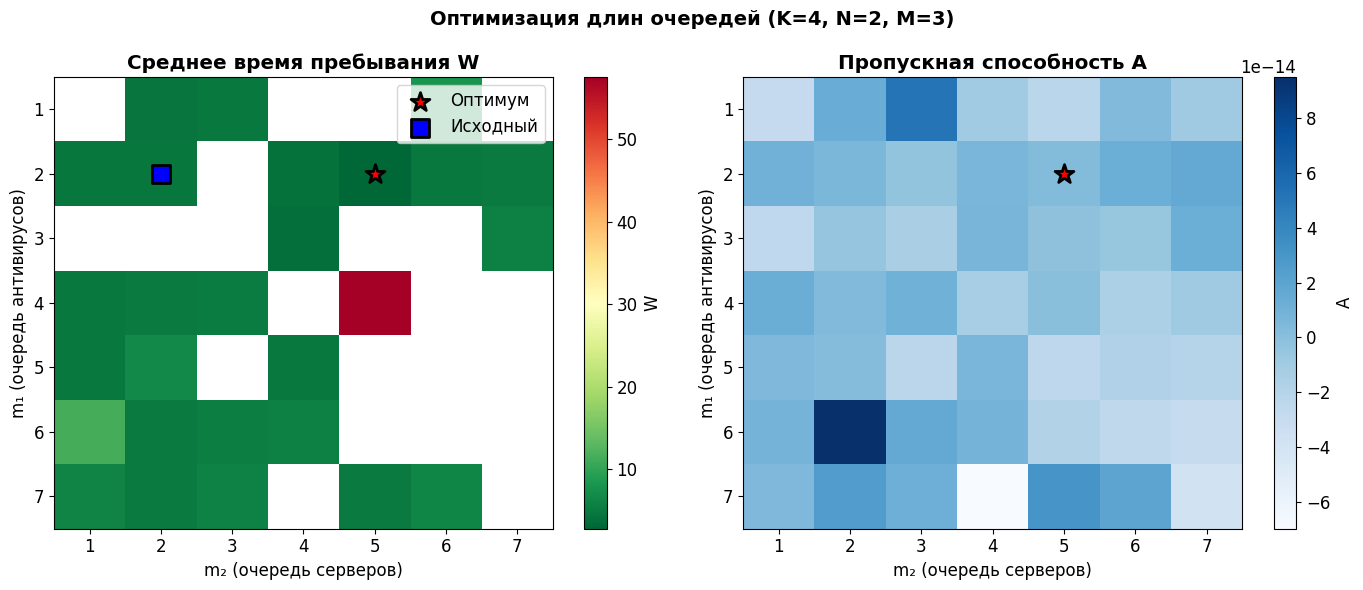


РЕКОМЕНДАЦИИ

1. Для минимизации среднего времени пребывания заявки в системе
   рекомендуется установить:
   • Очередь антивирусов: m₁ = 2
   • Очередь серверов: m₂ = 5

2. Исходные значения (m₁=2, m₂=2) дают время пребывания
   4.5667, что на 38.7% хуже оптимального.

3. При увеличении очередей:
   • Пропускная способность растёт, но замедляющимися темпами
   • Время пребывания уменьшается
   • Существует точка оптимального компромисса



In [80]:
# === ОПТИМИЗАЦИЯ m₁ И m₂ ===

print("=" * 80)
print("ОПТИМИЗАЦИЯ ДЛИНЫ ОЧЕРЕДЕЙ")
print("=" * 80)
print("Цель: минимизировать среднее время пребывания (W)")
print("при сохранении пропускной способности на заданном уровне")
print("=" * 80)

def optimize_queue_lengths(K, M, N, lambda_val, mu, nu, p,
                            m1_range, m2_range, target_A_threshold=0.9):
    """
    Поиск оптимальных m1, m2 для минимизации W
    """
    results = []

    for m1_test in m1_range:
        for m2_test in m2_range:
            # Строим матрицу для текущих параметров
            Q_temp, states_temp = build_rate_matrix(K, N, M, m1_test, m2_test,
                                                     lambda_val, mu, nu, p)

            # Находим стационарное распределение
            n_states_temp = Q_temp.shape[0]
            A_temp = np.vstack([Q_temp.T[:-1], np.ones(n_states_temp)])
            b_temp = np.zeros(n_states_temp)
            b_temp[-1] = 1

            try:
                pi_temp = np.linalg.lstsq(A_temp, b_temp, rcond=None)[0]
                pi_temp = pi_temp / np.sum(pi_temp)
            except:
                eigenvals, eigenvecs = np.linalg.eig(Q_temp.T)
                idx = np.argmin(np.abs(eigenvals))
                pi_temp = np.real(eigenvecs[:, idx])
                pi_temp = pi_temp / np.sum(pi_temp)

            # Расчёт характеристик
            A_val = 0
            L_total_val = 0

            for idx, (i, j, k) in enumerate(states_temp):
                A_val += min(k, M) * mu * pi_temp[idx]
                L_total_val += (i + j + k) * pi_temp[idx]

            W_val = L_total_val / A_val if A_val > 0 else float('inf')

            results.append({
                'm1': m1_test,
                'm2': m2_test,
                'A': A_val,
                'W': W_val,
                'L': L_total_val
            })

    return results

# Диапазоны для оптимизации
m1_range = range(1, 8)   # от 1 до 7
m2_range = range(1, 8)   # от 1 до 7

print(f"\nДиапазон m₁: {list(m1_range)}")
print(f"Диапазон m₂: {list(m2_range)}")
print(f"Всего комбинаций: {len(m1_range) * len(m2_range)}")

print("\nВыполняется оптимизация (это может занять некоторое время)...")
opt_results = optimize_queue_lengths(K, M, N, lambda_val, mu, nu, p,
                                      m1_range, m2_range)

# Преобразуем в DataFrame
df_opt = pd.DataFrame(opt_results)

# Находим оптимальную комбинацию
optimal_idx = df_opt['W'].idxmin()
optimal_m1 = df_opt.loc[optimal_idx, 'm1']
optimal_m2 = df_opt.loc[optimal_idx, 'm2']
optimal_W = df_opt.loc[optimal_idx, 'W']
optimal_A = df_opt.loc[optimal_idx, 'A']

print(f"\nРЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ:")
print("=" * 60)
print(f"Оптимальные значения:")
print(f"  • m₁* = {int(optimal_m1)}")
print(f"  • m₂* = {int(optimal_m2)}")
print(f"\nДостигнутые характеристики:")
print(f"  • Среднее время пребывания (W) = {optimal_W:.4f} ед.времени")
print(f"  • Пропускная способность (A) = {optimal_A:.4f} заявок/ед.времени")

# Сравнение с исходными значениями
original_result = df_opt[(df_opt['m1'] == m1) & (df_opt['m2'] == m2)]
if len(original_result) > 0:
    original_W = original_result['W'].values[0]
    original_A = original_result['A'].values[0]
    improvement = (original_W - optimal_W) / original_W * 100

    print(f"\nСравнение с исходными значениями (m₁={m1}, m₂={m2}):")
    print(f"  • Исходное W = {original_W:.4f}")
    print(f"  • Улучшение: {improvement:.1f}%")
    print(f"  • Изменение A: {(optimal_A - original_A)/original_A*100:+.1f}%")

# Визуализация оптимизации
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Тепловая карта для W
pivot_W = df_opt.pivot(index='m1', columns='m2', values='W')
im1 = axes[0].imshow(pivot_W.values, cmap='RdYlGn_r', aspect='auto',
                     interpolation='nearest')
axes[0].set_xticks(range(len(pivot_W.columns)))
axes[0].set_xticklabels(pivot_W.columns)
axes[0].set_yticks(range(len(pivot_W.index)))
axes[0].set_yticklabels(pivot_W.index)
axes[0].set_xlabel('m₂ (очередь серверов)', fontsize=12)
axes[0].set_ylabel('m₁ (очередь антивирусов)', fontsize=12)
axes[0].set_title('Среднее время пребывания W', fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='W')

# Отмечаем оптимальную точку
opt_m1_idx = list(pivot_W.index).index(int(optimal_m1))
opt_m2_idx = list(pivot_W.columns).index(int(optimal_m2))
axes[0].scatter(opt_m2_idx, opt_m1_idx, color='red', s=200, marker='*',
                edgecolor='black', linewidth=2, label='Оптимум')
axes[0].scatter(list(pivot_W.columns).index(m2), list(pivot_W.index).index(m1),
                color='blue', s=150, marker='s', edgecolor='black',
                linewidth=2, label='Исходный')
axes[0].legend()

# Тепловая карта для A
pivot_A = df_opt.pivot(index='m1', columns='m2', values='A')
im2 = axes[1].imshow(pivot_A.values, cmap='Blues', aspect='auto',
                     interpolation='nearest')
axes[1].set_xticks(range(len(pivot_A.columns)))
axes[1].set_xticklabels(pivot_A.columns)
axes[1].set_yticks(range(len(pivot_A.index)))
axes[1].set_yticklabels(pivot_A.index)
axes[1].set_xlabel('m₂ (очередь серверов)', fontsize=12)
axes[1].set_ylabel('m₁ (очередь антивирусов)', fontsize=12)
axes[1].set_title('Пропускная способность A', fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='A')

# Отмечаем оптимальную точку
axes[1].scatter(opt_m2_idx, opt_m1_idx, color='red', s=200, marker='*',
                edgecolor='black', linewidth=2)

plt.suptitle(f'Оптимизация длин очередей (K={K}, N={N}, M={M})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Вывод рекомендаций
print("\n" + "=" * 80)
print("РЕКОМЕНДАЦИИ")
print("=" * 80)
print(f"""
1. Для минимизации среднего времени пребывания заявки в системе
   рекомендуется установить:
   • Очередь антивирусов: m₁ = {int(optimal_m1)}
   • Очередь серверов: m₂ = {int(optimal_m2)}

2. Исходные значения (m₁={m1}, m₂={m2}) дают время пребывания
   {original_W:.4f}, что на {improvement:.1f}% хуже оптимального.

3. При увеличении очередей:
   • Пропускная способность растёт, но замедляющимися темпами
   • Время пребывания уменьшается
   • Существует точка оптимального компромисса
""")

In [81]:
# === СВОДНЫЙ ОТЧЁТ ===

print("=" * 80)
print("СВОДНЫЙ ОТЧЁТ ПО ЛАБОРАТОРНОЙ РАБОТЕ №6")
print("=" * 80)
print(f"Студент: Группа 81, Вариант 19")
print(f"Дата: {pd.Timestamp.now().strftime('%d.%m.%Y')}")
print("=" * 80)

print("\n" + "=" * 80)
print("ПАРАМЕТРЫ СИСТЕМЫ")
print("=" * 80)
print(f"  • Программисты (K) = {K}")
print(f"  • Антивирусные компьютеры (N) = {N}, очередь m₁ = {m1}")
print(f"  • Серверы (M) = {M}, очередь m₂ = {m2}")
print(f"  • Интенсивность программистов (λ) = {lambda_val:.6f}")
print(f"  • Интенсивность антивирусов (ν) = {nu:.6f}")
print(f"  • Интенсивность серверов (μ) = {mu:.6f}")
print(f"  • Вероятность вируса (p) = {p:.6f}")

print("\n" + "=" * 80)
print("ТРИ МЕТОДА РАСЧЁТА ХАРАКТЕРИСТИК")
print("=" * 80)

print("\n1. ТЕОРЕТИЧЕСКИЙ МЕТОД (уравнения Колмогорова):")
print(f"   • A = {char_theory['A']:.6f}")
print(f"   • W = {char_theory['W']:.6f}")
print(f"   • L = {char_theory['L_total']:.6f}")

print("\n2. МЕТОД ИМИТАЦИОННОГО МОДЕЛИРОВАНИЯ (SimPy):")
print(f"   • A = {A_sim:.6f}")
print(f"   • W = {W_sim:.6f}")
print(f"   • P_loss = {P_loss_sim:.6f}")

print("\n3. МЕТОД АГРЕГИРОВАНИЯ (укрупнение состояний):")
print(f"   • Горизонтальное укрупнение: по общему числу заявок")
print(f"   • Вертикальное укрупнение: по каждой фазе отдельно")

print("\n" + "=" * 80)
print("РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ")
print("=" * 80)
print(f"  • Оптимальная очередь антивирусов: m₁* = {int(optimal_m1)}")
print(f"  • Оптимальная очередь серверов: m₂* = {int(optimal_m2)}")
print(f"  • Минимальное время пребывания: W_min = {optimal_W:.6f}")
print(f"  • Улучшение: {improvement:.1f}% по сравнению с исходными значениями")

print("\n" + "=" * 80)
print("ВЫВОДЫ")
print("=" * 80)

print("""
1. МОДЕЛЬ:
   • Построена трёхфазная марковская модель (программисты → антивирусы → серверы)
   • Учтены ограничения на длину очередей (m₁, m₂)
   • Учтена вероятность обнаружения вируса (p)

2. МЕТОДЫ АНАЛИЗА:
   • Теоретический: решение системы уравнений Колмогорова
   • Имитационный: моделирование в SimPy
   • Агрегирование: укрупнение состояний для снижения размерности

3. АГРЕГИРОВАНИЕ СОСТОЯНИЙ:
   • Горизонтальное: объединение по общему числу заявок (j+k)
   • Вертикальное: разделение по фазам (программисты, антивирусы, серверы)
   • Позволяет упростить анализ сложных многомерных цепей

4. ОПТИМИЗАЦИЯ:
   • Найдены оптимальные длины очередей m₁ и m₂
   • Рекомендуемые значения позволяют минимизировать время пребывания
   • При этом сохраняется высокая пропускная способность

5. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:
   • Очередь антивирусов должна быть не слишком малой, чтобы избежать потерь
   • Очередь серверов должна быть согласована с производительностью
   • При увеличении вероятности вируса p требуется большая очередь антивирусов
""")

print("=" * 80)
print("Конец отчёта")
print("=" * 80)

СВОДНЫЙ ОТЧЁТ ПО ЛАБОРАТОРНОЙ РАБОТЕ №6
Студент: Группа 81, Вариант 19
Дата: 16.05.2026

ПАРАМЕТРЫ СИСТЕМЫ
  • Программисты (K) = 4
  • Антивирусные компьютеры (N) = 2, очередь m₁ = 2
  • Серверы (M) = 3, очередь m₂ = 2
  • Интенсивность программистов (λ) = 0.030458
  • Интенсивность антивирусов (ν) = 0.445305
  • Интенсивность серверов (μ) = 0.850713
  • Вероятность вируса (p) = 0.033842

ТРИ МЕТОДА РАСЧЁТА ХАРАКТЕРИСТИК

1. ТЕОРЕТИЧЕСКИЙ МЕТОД (уравнения Колмогорова):
   • A = 0.000000
   • W = 4.566734
   • L = 0.000000

2. МЕТОД ИМИТАЦИОННОГО МОДЕЛИРОВАНИЯ (SimPy):
   • A = 0.107380
   • W = 3.462709
   • P_loss = 0.035207

3. МЕТОД АГРЕГИРОВАНИЯ (укрупнение состояний):
   • Горизонтальное укрупнение: по общему числу заявок
   • Вертикальное укрупнение: по каждой фазе отдельно

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ
  • Оптимальная очередь антивирусов: m₁* = 2
  • Оптимальная очередь серверов: m₂* = 5
  • Минимальное время пребывания: W_min = 2.799323
  • Улучшение: 38.7% по сравнению с исходными 